## This is a sample Machine Learning project that exemplifies how to proceed Hierarchical Logistic Regression Multilevel Analysis (Logistic GLMM), using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
from statstests.process import stepwise
from sklearn.metrics import confusion_matrix, accuracy_score,\
    ConfusionMatrixDisplay, recall_score
from sklearn.metrics import roc_curve, auc
from scipy import stats
from scipy.stats import gaussian_kde
import time
import imageio
from IPython.display import Image, display
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Goes_travel = f(age, numb_of_kids). Hierarchical Logistic Regression (HLR) or Logistic Generalized Linear Mixed Models (GLMM). Logistic Multilevel (Nested) Regression Analysis.

This is a simple use-case for Logistic Generalized Linear Mixed Models (Logistic GLMM) of type Hierarchical Logistic Regression with 2 levels (HLM2): traveler (level 1) and country of origin (level 2). In this type of model, we have 2 levels (or layers) of contextual units: for level 1, we have the predictive variables age and numb_of_kids, which are features of each ij traveler (observation). These are nested inside a level-2 context, which does not have a predictive variable - although there could be level-2 predictors as well - but simply a random effect variable - ν₀ⱼ - on the intercept - although we could also have random effects on the slope, with ν₁ⱼ, ν₂ⱼ, etc. So, we have ij observations (travelers) nested inside different level-2 contexts (countries of origin) - with no level-2 predictors, but a level-2 (country) random effect on the intercept. The dependent variable - goes_travel - is a single qualitative variable (therefore a binary logistic case - not multinomial), whose logit regress on predictors at two different levels. Each country of origin is a different context (or level unit) for a specific group of travelers (observations). The final expression for the regression of the logit for this logistic GLMM example will thus contain all params from level 2 substituted at level 1, which basically is the level-2 ν₀ⱼ added to level-1 existing other ij params. For non-logistic HLM2 and HLM3, see other examples at this same project directory.

In [2]:
tourism_df = pd.read_csv('tourism.csv', delimiter=',')
tourism_df

,country_of_origin,goes_travel,age,numb_of_kids
0,France,yes,68,2
1,France,yes,37,0
2,France,yes,45,3
3,France,yes,59,2
4,France,yes,29,0
...,...,...,...,...
1617,Egypt,yes,30,0
1618,Egypt,yes,56,3
1619,Egypt,no,63,2
1620,Egypt,no,44,2


In [3]:
tourism_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   country_of_origin  1622 non-null   str  
 1   goes_travel        1622 non-null   str  
 2   age                1622 non-null   int64
 3   numb_of_kids       1622 non-null   int64
dtypes: int64(2), str(2)
memory usage: 50.8 KB


In [4]:
tourism_df.describe()

,age,numb_of_kids
count,1622.000000,1622.000000
mean,46.610974,1.444513
std,9.346953,1.058588
min,29.000000,0.000000
25%,39.000000,0.000000
50%,46.000000,2.000000
75%,53.000000,2.000000
max,70.000000,3.000000


In [5]:
tourism_df['goes_travel'].value_counts()

goes_travel
yes    979
no     643
Name: count, dtype: int64

In [6]:
tourism_df['country_of_origin'].value_counts().sort_index()

country_of_origin
Argentina         14
Australia         44
Austria           23
Belgium           37
Bolivia           13
Brazil            17
Bulgaria          30
Canada            49
Chile             27
China             86
Colombia          14
Costa Rica        48
Croatia           29
Denmark           13
Ecuador           26
Egypt             19
Finland           20
France           117
Germany           15
Greece           118
Honduras          11
Hungary            2
India             15
Ireland           26
Italy             65
Japan             24
Lithuania         20
Mexico            13
Montenegro        18
Morocco           45
Netherlands       18
New Zealand       32
Norway            14
Panama            26
Paraguay          33
Peru              61
Poland            24
Portugal          20
Romania           67
Russia            22
Scotland          47
Serbia            15
South Africa      42
South Korea        4
Spain             39
Sweden            21
Switzerland     

In [7]:
# dummification of 'goes_travel'
tourism_df.loc[tourism_df['goes_travel'] == 'yes', 'goes_travel'] = "1"
tourism_df.loc[tourism_df['goes_travel'] == 'no', 'goes_travel'] = "0"
tourism_df['goes_travel'] = tourism_df['goes_travel'].astype('int64')
tourism_df

,country_of_origin,goes_travel,age,numb_of_kids
0,France,1,68,2
1,France,1,37,0
2,France,1,45,3
3,France,1,59,2
4,France,1,29,0
...,...,...,...,...
1617,Egypt,1,30,0
1618,Egypt,1,56,3
1619,Egypt,0,63,2
1620,Egypt,0,44,2


In [8]:
# estimating multilevel logistic model with random effect on intercept
tourism_hlr_random_intercept_model=\
    BinomialBayesMixedGLM.from_formula('goes_travel ~ age + numb_of_kids',
                                       vc_formulas={'country_of_origin': '0 + C(country_of_origin)'},
                                       data=tourism_df)
tourism_hlr_random_intercept_model.fit_vb().summary()

,Type,Post. Mean,Post. SD,SD,SD (LB),SD (UB)
Intercept,M,0.4341,0.0530,,,
age,M,0.0153,0.0011,,,
numb_of_kids,M,-0.4257,0.0289,,,
country_of_origin,V,-0.6535,0.1002,0.520,0.426,0.636


In [9]:
# mean (ν₀ⱼ) and sd of random effect terms at tourism_hlr_random_intercept_model aggregated by country_of_origin
vb_result = tourism_hlr_random_intercept_model.fit_vb(scale_fe=True)
vb_result.random_effects(term='country_of_origin')

# observe that ν₀ⱼ is a level-2 param, i.e., all ij observations (level-1), nested inside one same j country (level-2) 
# context, has the same ν₀ⱼ.

,Mean,SD
C(country_of_origin)[Argentina],0.144324,0.385501
C(country_of_origin)[Australia],0.611104,0.295894
C(country_of_origin)[Austria],0.305730,0.337093
C(country_of_origin)[Belgium],-0.017218,0.288215
C(country_of_origin)[Bolivia],-0.256807,0.382820
C(country_of_origin)[Brazil],0.107174,0.363746
C(country_of_origin)[Bulgaria],-0.281765,0.302431
C(country_of_origin)[Canada],0.466047,0.273609
C(country_of_origin)[Chile],0.450062,0.333312
C(country_of_origin)[China],-0.487023,0.202440


In [10]:
# inserting random effect intercept terms from tourism_hlr_random_intercept_model into tourism_df

vb_result = tourism_hlr_random_intercept_model.fit_vb(scale_fe=True)

v0j = (
    vb_result
    .random_effects(term='country_of_origin')
    .reset_index()['Mean']
)

countries = pd.DataFrame({
    'country_of_origin': sorted(tourism_df['country_of_origin'].unique())
})

random_effects = pd.concat([countries, v0j], axis=1)

random_effects = random_effects.rename(columns={'Mean': 'v0j'})

if 'v0j' not in tourism_df.columns:
    tourism_df = tourism_df.merge(
        random_effects,
        on='country_of_origin',
        how='left'
    )

tourism_df

,country_of_origin,goes_travel,age,numb_of_kids,v0j
0,France,1,68,2,0.564716
1,France,1,37,0,0.564716
2,France,1,45,3,0.564716
3,France,1,59,2,0.564716
4,France,1,29,0,0.564716
...,...,...,...,...,...
1617,Egypt,1,30,0,-0.259726
1618,Egypt,1,56,3,-0.259726
1619,Egypt,0,63,2,-0.259726
1620,Egypt,0,44,2,-0.259726


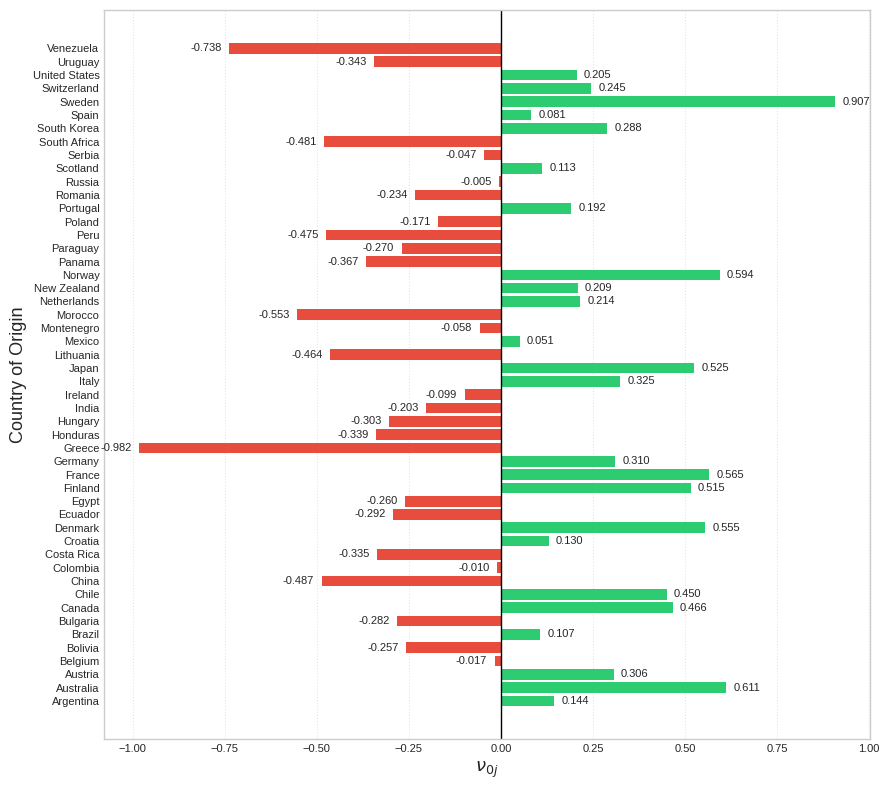

In [11]:
# Plot graph for visualizing the behaviour of v0j values, i.e., of random effects on intercept, per country

# Observe that these random effects (adjustments) on the logit (from which the phat=P(Y=1∣X) derivates), through the 
# level-2 (country of origin) ν₀ⱼ, do not exist on classical GLM logistic regression, and it's them that ultimately 
# contribute to a better logit regression on the level-1 predictive variables, in this case, as we have no level-2 
# predictors, only the random effect term ν₀ⱼ), and, in turn, contribute also to a better predictiveness of the 
# logistic model, in respect to its ROC curve (see at the end).

colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in random_effects['v0j']]

def label_point(x, y, ax):
    for xi, yi in zip(x, y):
        ax.text(
            xi + (0.02 if xi > 0 else -0.02),
            yi,
            f"{xi:.3f}",
            fontsize=8,
            verticalalignment='center',
            horizontalalignment='left' if xi > 0 else 'right'
        )

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(
    random_effects['country_of_origin'],
    random_effects['v0j'],
    color=colors
)

label_point(
    random_effects['v0j'],
    random_effects['country_of_origin'],
    ax
)

ax.axvline(0, color='black', linewidth=1)
ax.set_ylabel('Country of Origin', fontsize=13)
ax.set_xlabel(r'$\nu_{0j}$', fontsize=13)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='x', linestyle='dotted', alpha=0.5)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

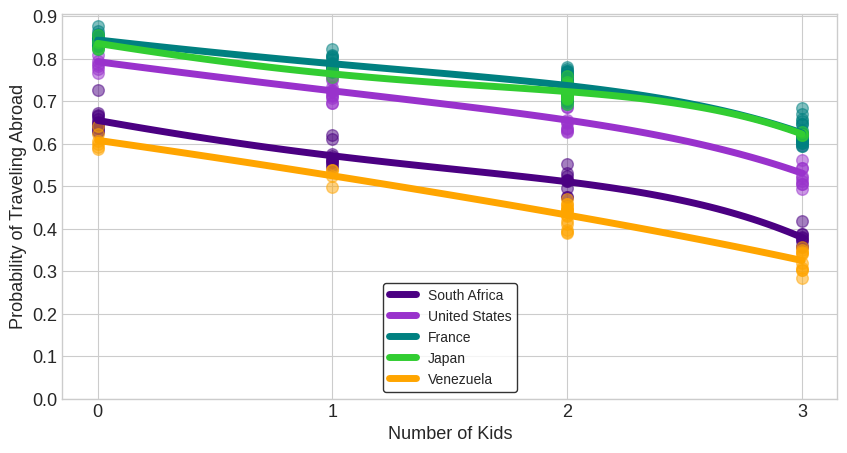

In [12]:
# Plot graph with the expected propbabilities that couples, resident in 5 example countries, go traveling abroad, 
# in function of the number of kids (independent sigmoid logistic predictive curves due to each country ν₀ⱼ value)

# Observe that, instead of a single logistic regression sigmoid curve, we have a regression curve per country, taking
# into account the particular country random effect on intercept (ν₀ⱼ), and of course, much better predictability
# regarding the whole model

vb_result = tourism_hlr_random_intercept_model.fit_vb(scale_fe=True)
gamma00 = vb_result.params[0]
gamma10 = vb_result.params[1]
gamma20 = vb_result.params[2]

tourism_df['fitted_probs_multilevel'] = (1) / (1 + np.exp(-(gamma00 +\
                                                            gamma10*tourism_df['age'] +\
                                                                gamma20*tourism_df['numb_of_kids'] +\
                                                                    tourism_df['v0j'])))

plt.figure(figsize=(10,5))
df1 = tourism_df[tourism_df['country_of_origin'] == 'South Africa']
df2 = tourism_df[tourism_df['country_of_origin'] == 'United States']
df3 = tourism_df[tourism_df['country_of_origin'] == 'France']
df4 = tourism_df[tourism_df['country_of_origin'] == 'Japan']
df5 = tourism_df[tourism_df['country_of_origin'] == 'Venezuela']
sns.regplot(x='numb_of_kids', y='fitted_probs_multilevel', data=df1, ci=False, order=5,
            scatter_kws={'color':'indigo', 's':70, 'alpha':0.5},
            line_kws={'color':'indigo', 'linewidth':5},
            label='South Africa')
sns.regplot(x='numb_of_kids', y='fitted_probs_multilevel', data=df2, ci=False, order=5,
            scatter_kws={'color':'darkorchid', 's':70, 'alpha':0.5},
            line_kws={'color':'darkorchid', 'linewidth':5},
            label='United States')
sns.regplot(x='numb_of_kids', y='fitted_probs_multilevel', data=df3, ci=False, order=5,
            scatter_kws={'color':'teal', 's':70, 'alpha':0.5},
            line_kws={'color':'teal', 'linewidth':5},
            label='France')
sns.regplot(x='numb_of_kids', y='fitted_probs_multilevel', data=df4, ci=False, order=5,
            scatter_kws={'color':'limegreen', 's':70, 'alpha':0.5},
            line_kws={'color':'limegreen', 'linewidth':5},
            label='Japan')
sns.regplot(x='numb_of_kids', y='fitted_probs_multilevel', data=df5, ci=False, order=5,
            scatter_kws={'color':'orange', 's':70, 'alpha':0.5},
            line_kws={'color':'orange', 'linewidth':5},
            label='Venezuela')
plt.xlabel('Number of Kids', fontsize=13)
plt.ylabel('Probability of Traveling Abroad', fontsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.tick_params(axis='x', labelsize=13)
plt.yticks(np.arange(0, 1, 0.1))
plt.xticks(np.arange(0, 4, 1))
legend_elements = [
    Line2D([0], [0], color='indigo', lw=5, label='South Africa'),
    Line2D([0], [0], color='darkorchid', lw=5, label='United States'),
    Line2D([0], [0], color='teal', lw=5, label='France'),
    Line2D([0], [0], color='limegreen', lw=5, label='Japan'),
    Line2D([0], [0], color='orange', lw=5, label='Venezuela')
]
plt.legend(handles=legend_elements, loc='lower center', fontsize=10,
           frameon=True, fancybox=True, edgecolor='black')
plt.show()

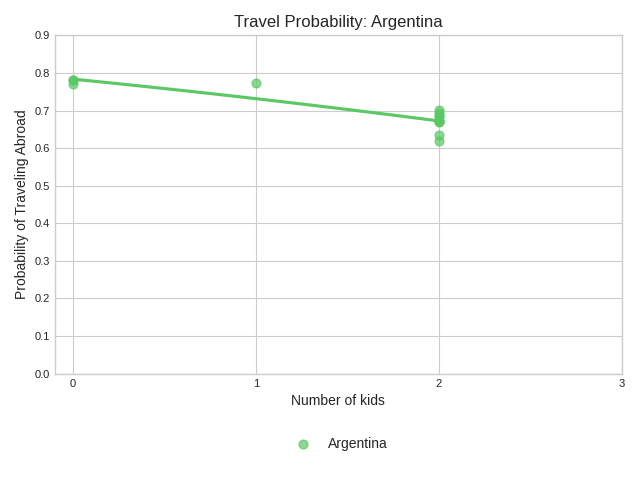

In [13]:
# Plot graph gif with prob of doing international travels x number of kids, per country, individually

countries = tourism_df['country_of_origin'].unique()
num_colors = len(countries)
color_country = dict(zip(countries, sns.color_palette('viridis', num_colors)))

frames = []

for country in sorted(countries):
    data = tourism_df[tourism_df['country_of_origin'] == country]
    fig, ax = plt.subplots()
    sns.regplot(x='numb_of_kids', y='fitted_probs_multilevel', data=data,
                color=color_country[country], ax=ax, ci=False, logistic=True,
                scatter_kws={'s':40, 'alpha':0.7})
    plt.title(f"Travel Probability: {country}", fontsize=12)
    plt.xlabel("Number of kids", fontsize=10)
    plt.ylabel("Probability of Traveling Abroad",
               fontsize=10)
    plt.tick_params(axis='x', labelsize=8)
    plt.tick_params(axis='y', labelsize=8)
    plt.yticks(np.arange(0, 1, 0.1))
    plt.xticks(np.arange(0, 4, 1))
    plt.tight_layout()
    ax.legend([f'{country}'], loc='upper center',
              bbox_to_anchor=(.5, -0.15), ncol=1)
    plt.tight_layout()
    plt_canvas = plt.get_current_fig_manager().canvas
    plt_canvas.draw()
    image = np.asarray(plt_canvas.buffer_rgba())  # RGBA
    image = image[:, :, :3]  # convert to RGB
    frames.append(image)
    plt.close()
imageio.mimsave('graphic_travel.gif', frames, fps=1, loop=0)
display(Image(filename='graphic_travel.gif'))

# this code cell might take a while for generating all countries' regression curves and finally mount the gif

In [14]:
# 3D-graph with probabilities of performing international travels for 5 example countries

zmin = min(df1['fitted_probs_multilevel'].min(),
           df2['fitted_probs_multilevel'].min(),
           df3['fitted_probs_multilevel'].min(),
           df4['fitted_probs_multilevel'].min(),
           df5['fitted_probs_multilevel'].min())

zmax = max(df1['fitted_probs_multilevel'].max(),
           df2['fitted_probs_multilevel'].max(),
           df3['fitted_probs_multilevel'].max(),
           df4['fitted_probs_multilevel'].max(),
           df5['fitted_probs_multilevel'].max())

fig = go.Figure()

# function for adding each surface
def add_surface(df, show_scale=False):
    fig.add_trace(go.Mesh3d(
        x=df['age'],
        y=df['numb_of_kids'],
        z=df['fitted_probs_multilevel'],
        intensity=df['fitted_probs_multilevel'],
        colorscale='Viridis',
        cmin=zmin,
        cmax=zmax,
        opacity=1,
        flatshading=True,
        showscale=show_scale
    ))

# adding the 5 surfaces
add_surface(df1, show_scale=True)
add_surface(df2)
add_surface(df3)
add_surface(df4)
add_surface(df5)

fig.update_layout(
    width=700,
    height=500,
    margin=dict(l=0, r=80, b=60, t=10),
    scene=dict(
        xaxis_title='age',
        yaxis_title='numb_of_kids',
        zaxis_title='goes_travel'
    )
)
fig.show()

In [15]:
# defining a traditional GLM logistic model for comparison with the GLMM model above

tourism_glm_logistic_model = sm.Logit.from_formula('goes_travel ~ age + numb_of_kids',
                        data=tourism_df).fit()
tourism_glm_logistic_model.summary()

Optimization terminated successfully.
         Current function value: 0.656306
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            goes_travel   No. Observations:                 1622
Model:                          Logit   Df Residuals:                     1619
Method:                           MLE   Df Model:                            2
Date:                Tue, 12 May 2026   Pseudo R-squ.:                 0.02268
Time:                        23:56:09   Log-Likelihood:                -1064.5
converged:                       True   LL-Null:                       -1089.2
Covariance Type:            nonrobust   LLR p-value:                 1.871e-11
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2925      0.272      1.076      0.282      -0.240       0.825
age              0.0150      0.006      2.356      0.018       0.003       0.027
numb_of_kids    -0.3870      0.057     -6.829      0.000      -0.498      -0.276
================================================================================
"""

In [16]:
# comparing both GLMM and GLM logistic models through their ROC curve - same dataset

def my_confusion_matrix(predicts, observed, cutoff, title):
    values = predicts.values
    binary_prediction = []
    for item in values:
        if item < cutoff:
            binary_prediction.append(0)
        else:
            binary_prediction.append(1)
    
    cm = confusion_matrix(binary_prediction, observed)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.xlabel('True')
    plt.ylabel('Classified')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.grid(False)
    plt.title(title+"\n")
    plt.show()

    sensitivity = recall_score(observed, binary_prediction, pos_label=1)
    specificity = recall_score(observed, binary_prediction, pos_label=0)
    accuracy = accuracy_score(observed, binary_prediction)

    indicators = pd.DataFrame({'Sensitivity':[sensitivity],
                                'Specificity':[specificity],
                                'Accuracy':[accuracy]})
    return indicators


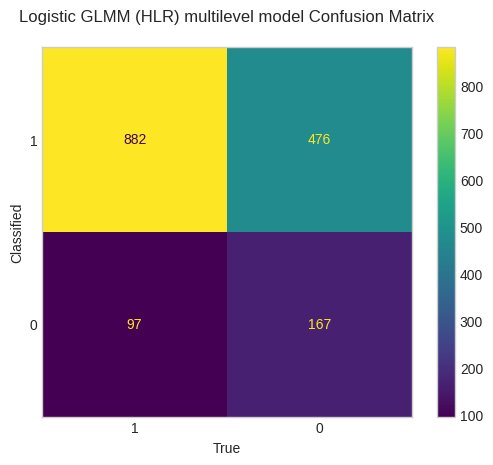

,Sensitivity,Specificity,Accuracy
0,0.900919,0.25972,0.646732


In [17]:
# Logistic GLMM (HLR) multilevel model
my_confusion_matrix(observed=tourism_df['goes_travel'],
                predicts=tourism_df['fitted_probs_multilevel'], cutoff=0.5,
                   title='Logistic GLMM (HLR) multilevel model Confusion Matrix')


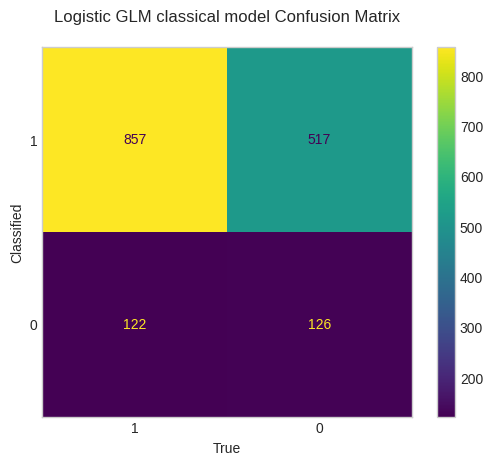

,Sensitivity,Specificity,Accuracy
0,0.875383,0.195956,0.606042


In [18]:
# Logistic GLM classical model
tourism_df['phat_glm'] = tourism_glm_logistic_model.predict()
my_confusion_matrix(observed=tourism_df['goes_travel'], 
                predicts=tourism_df['phat_glm'], cutoff=0.5,
                   title='Logistic GLM classical model Confusion Matrix')


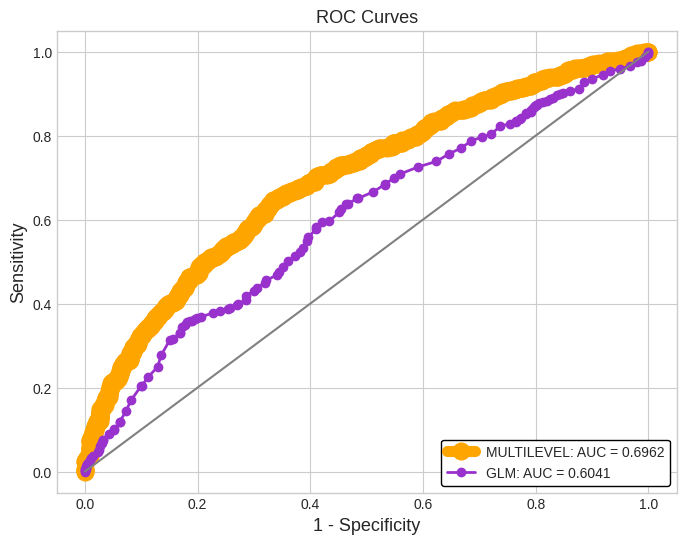

In [19]:
# ROC Curve
# Observe GLMM models, only by adding random effects on intercept, at level 2 (country of origin), increases 
# substantially ROC curve percentage value.

# Logistic GLMM (HLR) multilevel model
fpr_multilevel, tpr_multilevel, thresholds_multilevel = roc_curve(tourism_df['goes_travel'],
                                                                  tourism_df['fitted_probs_multilevel'])
roc_auc_multilevel = auc(fpr_multilevel, tpr_multilevel)

# Logistic GLM classical model
fpr_glm, tpr_glm, thresholds_glm = roc_curve(tourism_df['goes_travel'],
                                             tourism_df['phat_glm'])
roc_auc_glm = auc(fpr_glm, tpr_glm)

# AUROCs for Logistic GLMM (HLR) multilevel model and Logistic GLM classical model
pd.DataFrame({'AUROC MULTILEVEL':[round(roc_auc_multilevel,4)],
              'AUROC LOGIT':[round(roc_auc_glm,4)]})

# comparison between ROC curves in one same plot graph
plt.figure(figsize=(8,6))
plt.plot(fpr_multilevel, tpr_multilevel, '-o', color='orange', markersize=12,
         linewidth=8) # GLMM model
plt.plot(fpr_glm, tpr_glm, '-o', color='darkorchid', markersize=6,
         linewidth=2) # GLM model
plt.plot(fpr_glm, fpr_glm, color='gray')
plt.title('ROC Curves', fontsize=13)
plt.xlabel('1 - Specificity', fontsize=13)
plt.ylabel('Sensitivity', fontsize=13)
plt.legend(['MULTILEVEL: AUC = %g' % round(roc_auc_multilevel,4),
            'GLM: AUC = %g' % round(roc_auc_glm,4)],
           loc='lower right', fontsize=10, frameon=True, fancybox=True,
           framealpha=1, edgecolor='black')
plt.show()